### This code generates data for critical current in a Josephson fork-tip setup, and adds some random noise to the phase.
### Then, it reconstructs the phase and magnitude of the of the gap function from the noisy data.

#### Released under the MIT license. Authored by: Archisman Panigrahi (2026)

#### This code was utilized in the article `Imaging phase winding in topological superconductors with a fork-tip Josephson STM` by Vladislav Poliakov and Archisman Panigrahi.

In [1]:
using Plots
using Optim
using Random
using LinearAlgebra
using Printf
ENV["JULIA_PYTHONCALL_EXE"] = get(ENV, "JULIA_PYTHONCALL_EXE", "python3")
using PythonCall

In [2]:
lambdaF = 1
kF=2*pi/lambdaF;


I1_0 = 1; ## We use this for generating data, later we will recover it by treating the data as unknown and fitting it to the model.
eta = 2;
I2_0 = eta*I1_0; ## We use this for generating data, later we will recover it by treating the data as unknown and fitting it to the model.

In [3]:
function mask(r)
    return exp((r-lambdaF)*10)/(1+exp((r-lambdaF)*10))
end

mask (generic function with 1 method)

Here we define a mask function to neglect the data generated very close to the impurity, as there the semiclassical approximation is not valid.

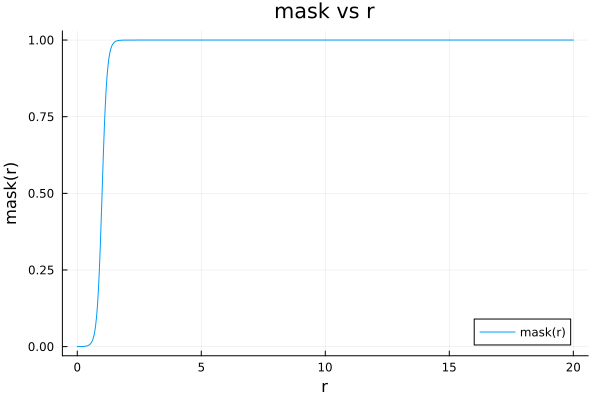

In [4]:
plot(mask, 0, 20, label="mask(r)", xlabel="r", ylabel="mask(r)", title="mask vs r")

In [5]:
function g(r)
    return cos(2*kF*(r+10^(-4)*lambdaF))*mask(r)/(kF*(r+10^(-4)*lambdaF)); ## We add a small number to r in the denominator to avoid division by zero at r=0.
end

g (generic function with 1 method)

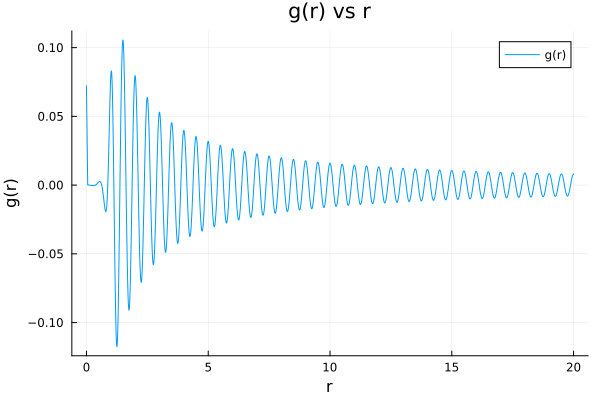

In [6]:
plot(g, 0, 20, label="g(r)", xlabel="r", ylabel="g(r)", title="g(r) vs r")

In [7]:
nX = 12;
nY = 12;

nX_points = 120; ### number of grid points in x
nY_points = 120; ### number of grid points in y

x_grid = range(-nX/2, nX/2, length=nX_points)
y_grid = range(-nY/2, nY/2, length=nY_points)

ximp1 = -3*lambdaF
ximp2 = 3*lambdaF

yimp1 = 0.0
yimp2 = 0.0

ix_mid = argmin(abs.(x_grid));

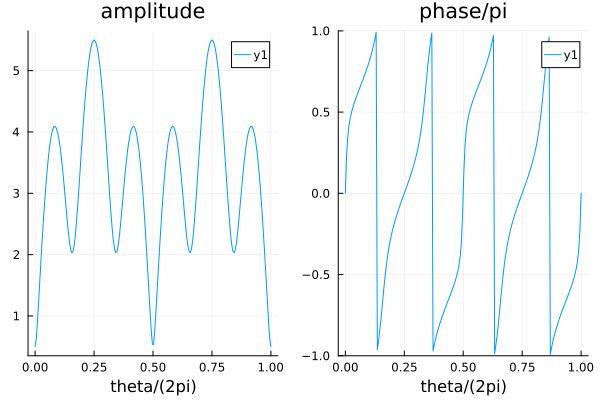

In [8]:
c0_coeff = 0
c_plus_2_coeff = -1
c_minus_2_coeff = -1.5
c_plus_4_coeff = 3
c_minus_4_coeff = 0
c_plus_6_coeff = 0
c_minus_6_coeff = 0

function delta(theta)
    return c0_coeff + c_plus_2_coeff * exp(2*im*theta) + c_minus_2_coeff * exp(-2*im*theta) + c_plus_4_coeff * exp(4*im*theta) + c_minus_4_coeff * exp(-4*im*theta) + c_plus_6_coeff*exp(6*im*theta) + c_minus_6_coeff*exp(-6*im*theta)
end

u_small = 0.1

theta_array = range(0, 2*pi, length=200)

delta_original_array = delta.(theta_array)
delta_mod_array = abs.(delta_original_array)
delta_phase_array = atan.(imag.(delta_original_array),real.(delta_original_array))

p1 = plot(theta_array/(2*pi), delta_mod_array, title="amplitude", xlabel="theta/(2pi)")
p2 = plot(theta_array/(2*pi), delta_phase_array/pi, ylims = (-1,1), title="phase/pi",  xlabel="theta/(2pi)")

plot(p1, p2, layout=(1,2))

In [9]:
### strength of the random noise added to the phase
random_strength=0.1;

total_signal = zeros(nX_points, nY_points)

pure_total_signal = zeros(nX_points, nY_points)
incoherent_signal = zeros(nX_points, nY_points)
incoherent_signal_zero_avg = zeros(nX_points, nY_points)
total_signal_zero_avg = zeros(nX_points, nY_points)

counter = 0;

for (i, x) in enumerate(x_grid)
    for (j, y) in enumerate(y_grid)
        r1 = sqrt((x-ximp1)^2 + (y-yimp1)^2)
        r2 = sqrt((x-ximp2)^2 + (y-yimp2)^2)

        phi1 = atan((y-yimp1),(x-ximp1))
        phi2 = atan((y-yimp2),(x-ximp2))


        ### Here we add a small random noise to each phase
        F1 = (c0_coeff + (u_small*g(r1)*delta(phi1 + randn()*random_strength)))*mask(r1)*mask(r2)*I1_0
        F2 = (c0_coeff + u_small*g(r2)*delta(phi2 + randn()*random_strength))*mask(r1)*mask(r2)*I2_0

        F1_pure = (c0_coeff + (u_small*g(r1)*delta(phi1)))*mask(r1)*mask(r2)*I1_0
        F2_pure = (c0_coeff + u_small*g(r2)*delta(phi2))*mask(r1)*mask(r2)*I2_0

        if(mask(r1)*mask(r2) < 0.5)
            counter += 1
        end

        pure_total_signal[i,j] = abs((F1_pure + F2_pure)^2)

        total_signal[i,j] = abs((F1 + F2)^2)

        incoherent_signal[i,j] = abs((F1^2 + F2^2))
    end
end

println("Number of points with mask < 0.5: ", counter)

avg_total_signal = sum(total_signal)/(nX_points*nY_points - counter)
avg_incoherent_signal = sum(incoherent_signal)/(nX_points*nY_points - counter)

incoherent_signal = incoherent_signal #.- avg_incoherent_signal*ones(size(incoherent_signal))
total_signal = total_signal #.- avg_total_signal*ones(size(total_signal))

println("Max of total_signal        = ", maximum(total_signal))
println("Max of pure_total_signal   = ", maximum(pure_total_signal))
println("Max of incoherent_signal   = ", maximum(incoherent_signal))

total_vmax = maximum(total_signal)/2
pure_total_vmax = maximum(pure_total_signal)/2
intensity_vmax = maximum(incoherent_signal)/2


Number of points with mask < 0.5: 628
Max of total_signal        = 0.01465865718359795
Max of pure_total_signal   = 0.014224730652935835
Max of incoherent_signal   = 0.01414444415437971


0.007072222077189855

In [10]:
maximum(total_signal)

0.01465865718359795

Matplotlib is building the font cache; this may take a moment.


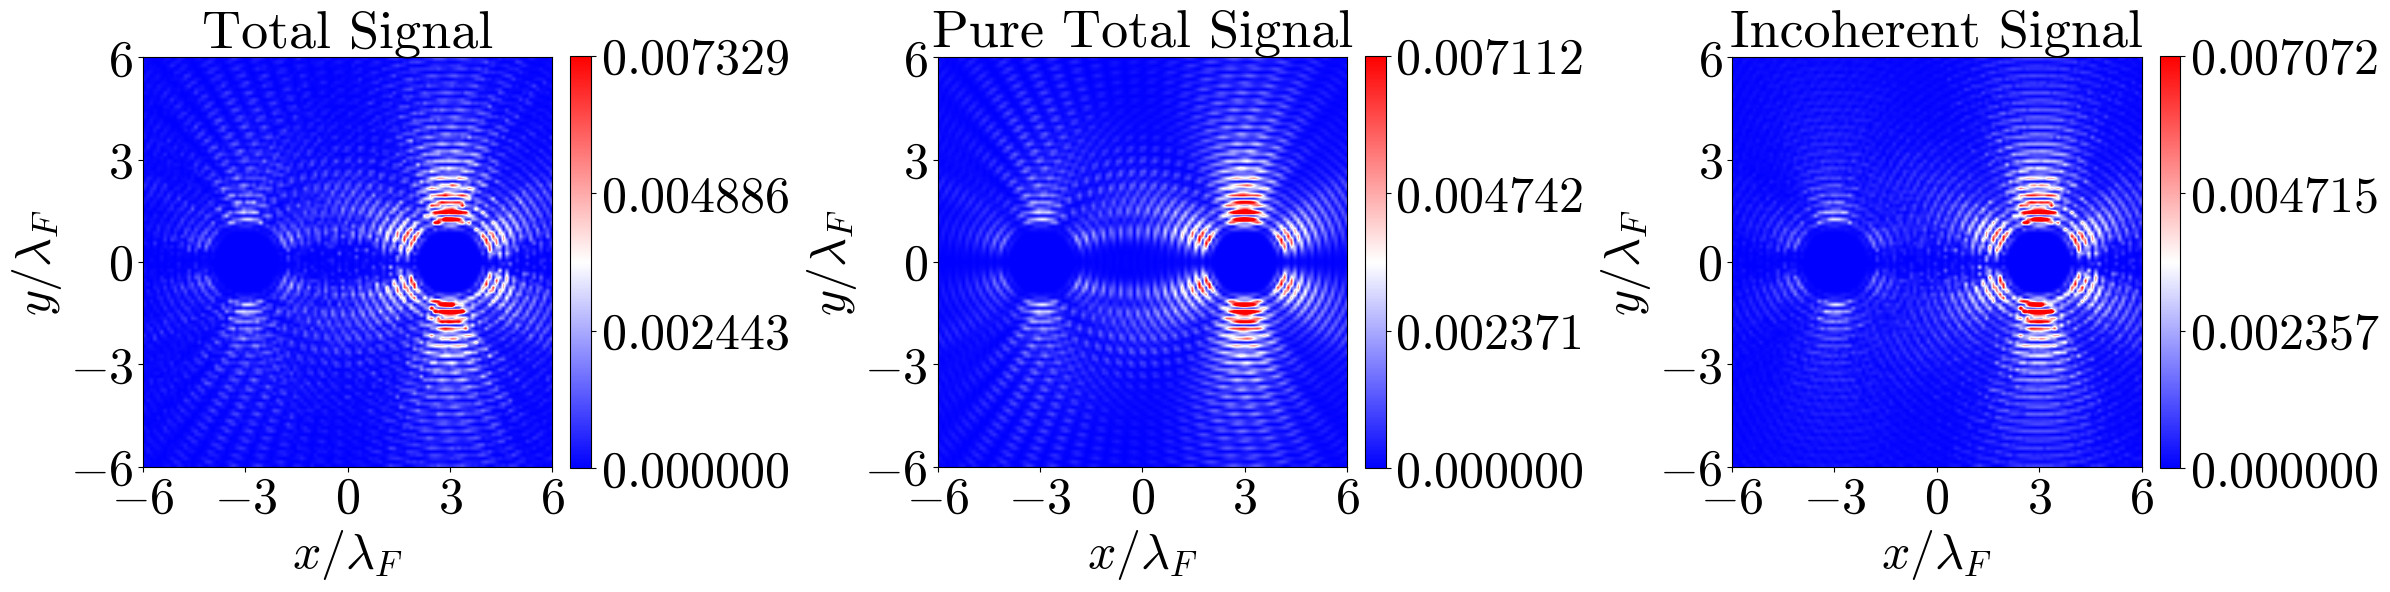

Exported PNGs and PDFs to: exported_plots


In [11]:
### Here we call a python script to generate publication quality plot because python's matplotlib plots look better than Julia's Plots.jl

python_code = raw"""
import sys
import os
import tempfile
os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp())
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["cmr10", "Computer Modern Roman", "DejaVu Serif"],
    "axes.formatter.use_mathtext": True,
    "axes.titlesize": 39,
    "axes.labelsize": 36,
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
})

(
    total_path,
    puretotal_path,
    incoherent_path,
    nx,
    ny,
    xmax,
    ymax,
    outpath,
    export_dir,
    lambdaF,
    total_vmax,
    pure_total_vmax,
    intensity_vmax,
    param_suffix
) = sys.argv[1:]

nx, ny = int(nx), int(ny)
xmax, ymax = float(xmax), float(ymax)
lambdaF = float(lambdaF)

total_vmax = float(total_vmax)
pure_total_vmax = float(pure_total_vmax)
intensity_vmax = float(intensity_vmax)


def load(path):
    return np.fromfile(path, dtype=np.float64).reshape((nx, ny), order="F")


total = load(total_path)
puretotal = load(puretotal_path)
incoherent = load(incoherent_path)


def plot_signal(ax, signal, cbar_label, vmin, vmax):
    x_edge = xmax / (2 * lambdaF)
    y_edge = ymax / (2 * lambdaF)

    im = ax.imshow(
        signal.T,
        origin="lower",
        extent=(-x_edge, x_edge, -y_edge, y_edge),
        interpolation="bilinear",
        cmap="bwr",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xlabel(r"$x/\lambda_F$")
    ax.set_ylabel(r"$y/\lambda_F$")
    ax.set_title(cbar_label)

    ax.set_xlim(-x_edge, x_edge)
    ax.set_ylim(-y_edge, y_edge)

    ax.set_xticks(np.linspace(-x_edge, x_edge, 5))
    ax.set_yticks(np.linspace(-y_edge, y_edge, 5))

    ax.set_aspect("equal")

    cbar = plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    lo, hi = im.get_clim()
    cbar.set_ticks(np.linspace(lo, hi, 4))
    cbar.ax.tick_params(labelsize=36)

    return im



fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# Total Signal: [0, +total_vmax]
plot_signal(
    axs[0],
    total,
    "Total Signal",
    0,
    total_vmax
)

# Pure Total Signal: [0, pure_total_vmax]
plot_signal(
    axs[1],
    puretotal,
    "Pure Total Signal",
    0,
    pure_total_vmax
)

# Incoherent Signal: [0, intensity_vmax]
plot_signal(
    axs[2],
    incoherent,
    "Incoherent Signal",
    0,
    intensity_vmax
)

fig.tight_layout()
fig.savefig(outpath, dpi=100, bbox_inches="tight")

os.makedirs(export_dir, exist_ok=True)
fig.savefig(os.path.join(export_dir, f"generated_signals_combined_{param_suffix}.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(export_dir, f"generated_signals_combined_{param_suffix}.pdf"), bbox_inches="tight")
plt.close(fig)


# Export individual panels as PNG and PDF


def export_single(signal, base_title, vmin, vmax, basename):
    fig, ax = plt.subplots(figsize=(8, 8))

    plot_signal(
        ax,
        signal,
        base_title,
        vmin,
        vmax
    )

    fig.tight_layout()
    fig.savefig(
        os.path.join(export_dir, f"{basename}_{param_suffix}.png"),
        dpi=150,
        bbox_inches="tight"
    )
    fig.savefig(
        os.path.join(export_dir, f"{basename}_{param_suffix}.pdf"),
        bbox_inches="tight"
    )
    plt.close(fig)


export_single(
    total,
    "Total Signal",
    0,
    total_vmax,
    "total_signal"
)

export_single(
    puretotal,
    "Pure Total Signal",
    0,
    pure_total_vmax,
    "pure_total_signal"
)

export_single(
    incoherent,
    "Incoherent Signal",
    0,
    intensity_vmax,
    "incoherent_signal"
)
"""


function write_bin(path, M)
    open(path, "w") do io
        write(io, Float64.(M))
    end
end


tmpdir = mktempdir()

write_bin(joinpath(tmpdir, "total.bin"), total_signal)
write_bin(joinpath(tmpdir, "puretotal.bin"), pure_total_signal)
write_bin(joinpath(tmpdir, "incoherent.bin"), incoherent_signal)

nx, ny = size(total_signal)

outpath = joinpath(tmpdir, "out.png")

export_dir = "exported_plots"
param_suffix = @sprintf(
    "I1_%.3f_I2_%.3f_c+2_%.3f%+.3fi_c-2_%.3f%+.3fi_c+4_%.3f%+.3fi_c-4_%.3f%+.3fi_c+6_%.3f%+.3fi_c-6_%.3f%+.3fi",
    I1_0,
    I2_0,
    real(c_plus_2_coeff), imag(c_plus_2_coeff),
    real(c_minus_2_coeff), imag(c_minus_2_coeff),
    real(c_plus_4_coeff), imag(c_plus_4_coeff),
    real(c_minus_4_coeff), imag(c_minus_4_coeff),
    real(c_plus_6_coeff), imag(c_plus_6_coeff),
    real(c_minus_6_coeff), imag(c_minus_6_coeff),
)


run(pipeline(
    `python3 - $(joinpath(tmpdir,"total.bin"))
              $(joinpath(tmpdir,"puretotal.bin"))
              $(joinpath(tmpdir,"incoherent.bin"))
              $nx $ny $nX $nY
              $outpath
              $export_dir
              $lambdaF
              $total_vmax
              $pure_total_vmax
              $intensity_vmax
              $param_suffix`,
    stdin=IOBuffer(python_code)
))


display("image/png", read(outpath))

println("Exported PNGs and PDFs to: ", export_dir)

## Direct complex Fourier-coefficient fit

This fitting section treats the generated signal as the data and fits it with the following form.

$$I_c^2(x,y)=|F_1(x,y)+F_2(x,y)|^2$$

During fitting, `I1_0` is fixed to `1`, while the strength of `I2_0` with respect to `I1_0` and the six complex Fourier coefficients are optimized.

Since the overall phase cannot be determined due to the gauge degree of freedom, after fitting, teh solution is rotated with an overall phase so that the coefficient with maximum magnitude is real and positive.

Also, to speed up the fitting procedure, the optimizer uses a subsampled grid through `stride`.

In [12]:
# Here we create a copy of the generated signal
fit_mask12 = zeros(nX_points, nY_points)
fit_g1 = zeros(nX_points, nY_points)
fit_g2 = zeros(nX_points, nY_points)
fit_phi1 = zeros(nX_points, nY_points)
fit_phi2 = zeros(nX_points, nY_points)

for (i, x) in enumerate(x_grid), (j, y) in enumerate(y_grid)
    r1 = sqrt((x-ximp1)^2 + (y-yimp1)^2)
    r2 = sqrt((x-ximp2)^2 + (y-yimp2)^2)

    fit_mask12[i,j] = mask(r1) * mask(r2)
    fit_g1[i,j] = u_small * g(r1)
    fit_g2[i,j] = u_small * g(r2)
    fit_phi1[i,j] = atan(y-yimp1, x-ximp1)
    fit_phi2[i,j] = atan(y-yimp2, x-ximp2)
end

In [13]:
# Here we define the angular harmonics coefficients
const fit_coeff_names = [
    :c_plus_2_coeff,
    :c_minus_2_coeff,
    :c_plus_4_coeff,
    :c_minus_4_coeff,
    :c_plus_6_coeff,
    :c_minus_6_coeff,
]
const fit_harmonics = [2, -2, 4, -4, 6, -6]

function delta_from_coeffs(theta, coeffs)
    z = zero(ComplexF64)
    for (c, n) in zip(coeffs, fit_harmonics)
        z += c * exp(im * n * theta)
    end
    return z
end

function fitted_total_signal(coeffs, I2_fit; rows=axes(fit_phi1, 1), cols=axes(fit_phi1, 2))
    Δ1 = delta_from_coeffs.(fit_phi1[rows, cols], Ref(coeffs))
    Δ2 = delta_from_coeffs.(fit_phi2[rows, cols], Ref(coeffs))

    # I1_0 is fixed to 1 during fitting. I2_fit is the fitted I2_0.
    F1 = (c0_coeff .+ fit_g1[rows, cols] .* Δ1) .* fit_mask12[rows, cols]
    F2 = (c0_coeff .+ fit_g2[rows, cols] .* Δ2) .* fit_mask12[rows, cols] .* I2_fit
    return abs2.(F1 .+ F2)
end

function canonicalize_reference_coeff(coeffs, ref_idx)
    if abs(coeffs[ref_idx]) == 0
        return coeffs, ref_idx
    end

    coeffs_rot = coeffs .* exp(-im * angle(coeffs[ref_idx]))
    coeffs_rot[ref_idx] = ComplexF64(abs(coeffs[ref_idx]), 0.0)
    return coeffs_rot, ref_idx
end

function canonicalize_max_coeff(coeffs)
    max_idx = argmax(abs.(coeffs))
    return canonicalize_reference_coeff(coeffs, max_idx)
end

# Here we compute the net phase winding
function phase_winding(coeffs; n_samples=4096)
    theta = range(0, 2pi; length=n_samples + 1)
    Delta = delta_from_coeffs.(theta, Ref(coeffs))
    phase_steps = angle.(conj.(Delta[1:end-1]) .* Delta[2:end])
    return sum(phase_steps) / (2pi)
end

function objectives_are_similar(obj, best_obj; rtol=1e-3, atol=1e-12)
    return obj <= best_obj + max(atol, rtol * abs(best_obj))
end

objectives_are_similar (generic function with 1 method)

In [14]:
# Here we make one of the coefficients real and positive
function unpack_gauge_params(p, gauge_idx)
    coeffs = Vector{ComplexF64}(undef, length(fit_harmonics))
    coeffs[gauge_idx] = exp(p[1]) + 0im

    q = 2
    for idx in eachindex(coeffs)
        if idx == gauge_idx
            continue
        end
        coeffs[idx] = p[q] + im*p[q+1]
        q += 2
    end

    I2_fit = exp(p[end])
    return coeffs, I2_fit
end

function pack_initial_params(gauge_idx, coeff_scale, I2_start; rng=Random.default_rng())
    p = zeros(12)
    p[1] = log(coeff_scale)

    q = 2
    for idx in eachindex(fit_harmonics)
        if idx == gauge_idx
            continue
        end
        p[q] = coeff_scale * (2rand(rng) - 1)
        p[q+1] = coeff_scale * (2rand(rng) - 1)
        q += 2
    end

    p[end] = log(I2_start)
    return p
end

function complex_coeff_objective(p, gauge_idx, signal, rows, cols)
    coeffs, I2_fit = unpack_gauge_params(p, gauge_idx)
    pred = fitted_total_signal(coeffs, I2_fit; rows=rows, cols=cols)
    signal_sample = signal[rows, cols]
    return sum(abs2, pred .- signal_sample) / length(signal_sample)
end

complex_coeff_objective (generic function with 1 method)

In [15]:
# The actual fitting is computed in this cell

function estimate_coeff_scale(signal)
    signal_amp = sqrt(maximum(abs.(signal)))
    geom_amp = maximum(abs.(fit_mask12 .* max.(abs.(fit_g1), abs.(fit_g2))))
    if geom_amp <= eps(Float64)
        return 1.0
    end
    return max(signal_amp / geom_amp, 1e-3)
end

function fit_one_gauge(signal, gauge_idx; n_restarts=10, coeff_scale=nothing,
                       I2_start=1.0, seed=1234, iterations=1500, stride=3,
                       objective_rtol=1e-3, objective_atol=1e-12)
    rng = MersenneTwister(seed + gauge_idx)
    rows = first(axes(signal, 1)):stride:last(axes(signal, 1))
    cols = first(axes(signal, 2)):stride:last(axes(signal, 2))
    scale0 = isnothing(coeff_scale) ? estimate_coeff_scale(signal) : coeff_scale

    starts = Vector{Vector{Float64}}()
    push!(starts, pack_initial_params(gauge_idx, scale0, I2_start; rng=rng))
    for scale_factor in (0.25, 0.5, 1.0, 2.0)
        push!(starts, pack_initial_params(gauge_idx, scale0 * scale_factor, I2_start; rng=rng))
    end
    for _ in 1:n_restarts
        scale_factor = 10.0 ^ (-1.0 + 2.0 * rand(rng))
        push!(starts, pack_initial_params(gauge_idx, scale0 * scale_factor, I2_start; rng=rng))
    end

    results = Any[]
    for p0 in starts
        result = optimize(
            p -> complex_coeff_objective(p, gauge_idx, signal, rows, cols),
            p0,
            LBFGS(),
            Optim.Options(iterations=iterations)
        )
        push!(results, result)
    end


    best_obj = minimum(Optim.minimum.(results))
    similar_results = filter(
        result -> objectives_are_similar(Optim.minimum(result), best_obj;
                                          rtol=objective_rtol, atol=objective_atol),
        results,
    )
    increasing_results = filter(similar_results) do result
        coeffs_result, _ = unpack_gauge_params(Optim.minimizer(result), gauge_idx)
        phase_winding(coeffs_result) > 0.5
    end
    preferred_results = isempty(increasing_results) ? similar_results : increasing_results
    best_result = preferred_results[argmin(Optim.minimum.(preferred_results))]
    best_obj = Optim.minimum(best_result)

    coeffs, I2_fit = unpack_gauge_params(Optim.minimizer(best_result), gauge_idx)
    max_idx = argmax(abs.(coeffs))
    pred = fitted_total_signal(coeffs, I2_fit)
    residual_norm = norm(vec(pred .- signal))
    return (
        gauge_idx=gauge_idx,
        gauge_name=fit_coeff_names[gauge_idx],
        coeffs=coeffs,
        I2_fit=I2_fit,
        objective=best_obj,
        residual_norm=residual_norm,
        max_idx=max_idx,
        max_name=fit_coeff_names[max_idx],
        gauge_is_max=(max_idx == gauge_idx),
        phase_winding=phase_winding(coeffs),
        result=best_result,
    )
end

function fit_complex_fourier_coeffs(signal; n_restarts=10, seed=1234, coeff_scale=nothing, stride=3,
                                    objective_rtol=1e-3, objective_atol=1e-12)
    fits = [
        fit_one_gauge(signal, gauge_idx;
            n_restarts=n_restarts,
            coeff_scale=coeff_scale,
            seed=seed,
            stride=stride,
            objective_rtol=objective_rtol,
            objective_atol=objective_atol,
        )
        for gauge_idx in eachindex(fit_harmonics)
    ]

    valid_fits = filter(fit -> fit.gauge_is_max, fits)
    candidate_fits = isempty(valid_fits) ? fits : valid_fits
    best_obj = minimum(fit.objective for fit in candidate_fits)
    similar_fits = filter(
        fit -> objectives_are_similar(fit.objective, best_obj;
                                      rtol=objective_rtol, atol=objective_atol),
        candidate_fits,
    )
    increasing_fits = filter(fit -> fit.phase_winding > 0.5, similar_fits)
    preferred_fits = isempty(increasing_fits) ? similar_fits : increasing_fits
    best_fit = preferred_fits[argmin([fit.objective for fit in preferred_fits])]

    coeffs_canon, max_idx = canonicalize_max_coeff(best_fit.coeffs)
    pred = fitted_total_signal(coeffs_canon, best_fit.I2_fit)

    return (
        coeffs=coeffs_canon,
        I1_fit=1.0,
        I2_fit=best_fit.I2_fit,
        fitted_signal=pred,
        residual=pred .- signal,
        residual_norm=norm(vec(pred .- signal)),
        objective=sum(abs2, pred .- signal) / length(signal),
        max_idx=max_idx,
        max_name=fit_coeff_names[max_idx],
        phase_winding=phase_winding(coeffs_canon),
        gauge_fit=best_fit,
        all_gauge_fits=fits,
    )
end

fit_result = fit_complex_fourier_coeffs(total_signal; n_restarts=10, seed=42, stride=3)

recovered_coeffs = fit_result.coeffs
recovered_I1_0 = fit_result.I1_fit
recovered_I2_0 = fit_result.I2_fit
fitted_signal = fit_result.fitted_signal

recovered_c_plus_2_coeff  = recovered_coeffs[1]
recovered_c_minus_2_coeff = recovered_coeffs[2]
recovered_c_plus_4_coeff  = recovered_coeffs[3]
recovered_c_minus_4_coeff = recovered_coeffs[4]
recovered_c_plus_6_coeff  = recovered_coeffs[5]
recovered_c_minus_6_coeff = recovered_coeffs[6]

recovered_max_coeff = recovered_coeffs[fit_result.max_idx]
if maximum(abs.(recovered_coeffs)) > eps(Float64)
    @assert real(recovered_max_coeff) > 0
    @assert isapprox(imag(recovered_max_coeff), 0.0; atol=1e-10)
end

println("Best gauge during optimization: ", fit_result.gauge_fit.gauge_name)
println("Coefficient with max magnitude after canonicalization: ", fit_result.max_name)
println("Max coefficient after canonicalization = ", recovered_max_coeff, "  (real positive)")
println("Recovered I1_0 = ", recovered_I1_0, "  (fixed during fit)")
println("Recovered I2_0 = ", recovered_I2_0)
println("Recovered phase winding = ", fit_result.phase_winding, "  (positive preferred among similar fits)")
println("Residual norm = ", fit_result.residual_norm)
println("Mean squared residual = ", fit_result.objective)
println()
println("Recovered coefficients:")
for (name, coeff) in zip(fit_coeff_names, recovered_coeffs)
    println("  ", name, " = ", coeff, "    |c| = ", abs(coeff))
end

Best gauge during optimization: c_minus_2_coeff
Coefficient with max magnitude after canonicalization: c_plus_4_coeff
Max coefficient after canonicalization = 3.049280679671651 + 0.0im  (real positive)
Recovered I1_0 = 1.0  (fixed during fit)
Recovered I2_0 = 2.024011026875175
Recovered phase winding = 4.0  (positive preferred among similar fits)
Residual norm = 0.03538834360967392
Mean squared residual = 8.696769884974644e-8

Recovered coefficients:
  c_plus_2_coeff = -0.9926800947302187 + 0.01167393111842932im    |c| = 0.9927487351497124
  c_minus_2_coeff = -1.2692194270428419 + 0.06486315586991134im    |c| = 1.2708757543412197
  c_plus_4_coeff = 3.049280679671651 + 0.0im    |c| = 3.049280679671651
  c_minus_4_coeff = 0.084796647337354 - 0.02375437079496952im    |c| = 0.08806101027992176
  c_plus_6_coeff = -0.04269952763719872 - 0.023092795161215197im    |c| = 0.04854407120130883
  c_minus_6_coeff = -0.03496744465492064 - 0.09168591246293965im    |c| = 0.09812761451220942


In [16]:
### Here we print the true and the recovered coefficients
true_coeffs = ComplexF64[
    c_plus_2_coeff,
    c_minus_2_coeff,
    c_plus_4_coeff,
    c_minus_4_coeff,
    c_plus_6_coeff,
    c_minus_6_coeff,
]
true_max_abs = maximum(abs.(true_coeffs))
true_max_indices = findall(abs.(true_coeffs) .>= true_max_abs - 1e-10)

true_coeffs_canon, true_comparison_idx = canonicalize_reference_coeff(true_coeffs, fit_result.max_idx)

println("True coefficients, rotated to the recovered max-real convention:")
for (name, coeff) in zip(fit_coeff_names, true_coeffs_canon)
    println("  ", name, " = ", coeff, "    |c| = ", abs(coeff))
end
println("True coefficient(s) with max magnitude: ", fit_coeff_names[true_max_indices])
println("Comparison gauge coefficient: ", fit_coeff_names[true_comparison_idx])
println()
println("Recovered coefficients, after aligning true coefficients to the gauge choice convention:")
for (name, recovered, truth) in zip(fit_coeff_names, recovered_coeffs, true_coeffs_canon)
    println("  ", name, " = ", recovered - truth)
end

True coefficients, rotated to the recovered max-real convention:
  c_plus_2_coeff = -1.0 + 0.0im    |c| = 1.0
  c_minus_2_coeff = -1.5 + 0.0im    |c| = 1.5
  c_plus_4_coeff = 3.0 + 0.0im    |c| = 3.0
  c_minus_4_coeff = 0.0 + 0.0im    |c| = 0.0
  c_plus_6_coeff = 0.0 + 0.0im    |c| = 0.0
  c_minus_6_coeff = 0.0 + 0.0im    |c| = 0.0
True coefficient(s) with max magnitude: [:c_plus_4_coeff]
Comparison gauge coefficient: c_plus_4_coeff

Recovered coefficients, after aligning true coefficients to the gauge choice convention:
  c_plus_2_coeff = 0.007319905269781324 + 0.01167393111842932im
  c_minus_2_coeff = 0.23078057295715815 + 0.06486315586991134im
  c_plus_4_coeff = 0.04928067967165095 + 0.0im
  c_minus_4_coeff = 0.084796647337354 - 0.02375437079496952im
  c_plus_6_coeff = -0.04269952763719872 - 0.023092795161215197im
  c_minus_6_coeff = -0.03496744465492064 - 0.09168591246293965im


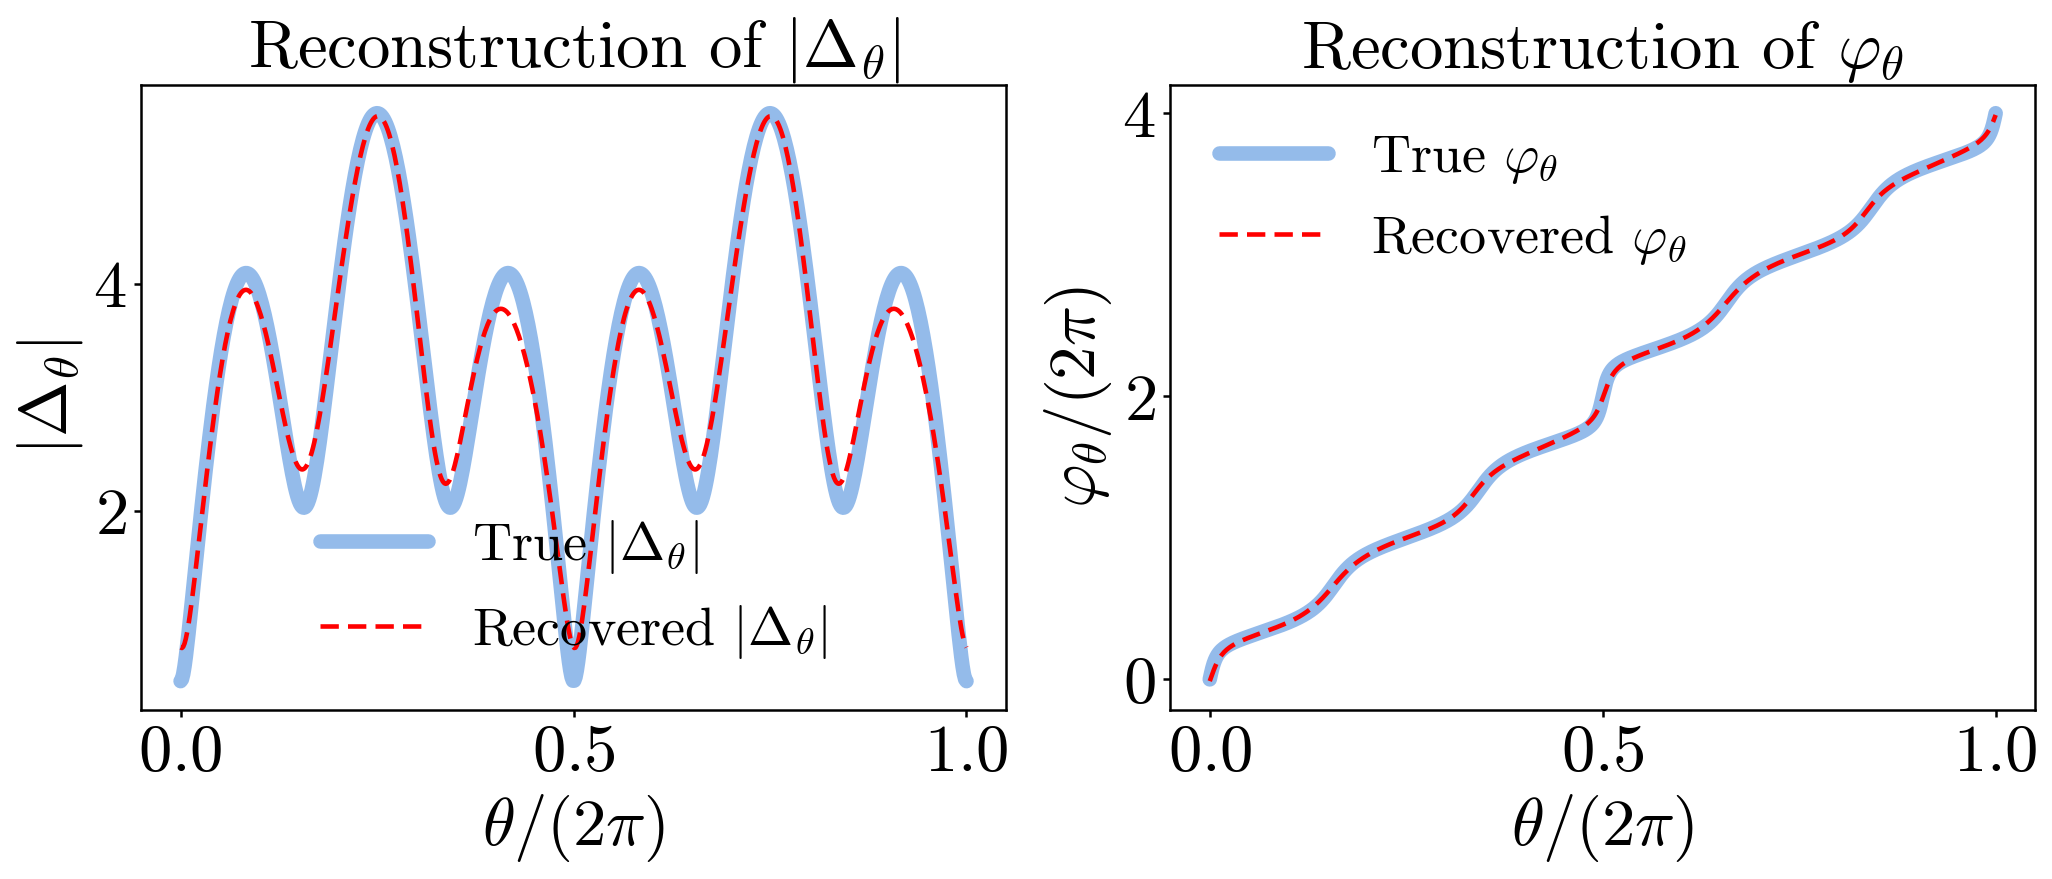

Exported PDFs to: exported_plots


In [19]:
# Here we plot the recovered vs true amplitude and phase of Delta(theta) over all angles.

function unwrap_phase(phi)
    out = collect(phi)
    for k in 2:length(out)
        step = out[k] - out[k-1]
        if step > pi
            out[k:end] .-= 2*pi
        elseif step < -pi
            out[k:end] .+= 2*pi
        end
    end
    return out
end

theta_fit_plot = range(0, 2*pi, length=600)

Delta_true_plot = delta_from_coeffs.(theta_fit_plot, Ref(true_coeffs_canon))
Delta_recovered_plot = delta_from_coeffs.(theta_fit_plot, Ref(recovered_coeffs))

amp_true_plot = Float64.(abs.(Delta_true_plot))
amp_recovered_plot = Float64.(abs.(Delta_recovered_plot))

phase_true_plot = Float64.(unwrap_phase(angle.(Delta_true_plot)))
phase_recovered_plot = Float64.(unwrap_phase(angle.(Delta_recovered_plot)))

x_delta_plot = Float64.(theta_fit_plot ./ (2*pi))
y_amp_true = amp_true_plot
y_amp_recovered = amp_recovered_plot
y_phase_true = phase_true_plot ./ (2*pi)
y_phase_recovered = phase_recovered_plot ./ (2*pi)

param_suffix_delta = @sprintf(
    "I1fit_%.3f_I2fit_%.3f_max_%s_c+2_%.3f%+.3fi_c-2_%.3f%+.3fi_c+4_%.3f%+.3fi_c-4_%.3f%+.3fi_c+6_%.3f%+.3fi_c-6_%.3f%+.3fi",
    recovered_I1_0,
    recovered_I2_0,
    String(fit_result.max_name),
    real(recovered_coeffs[1]), imag(recovered_coeffs[1]),
    real(recovered_coeffs[2]), imag(recovered_coeffs[2]),
    real(recovered_coeffs[3]), imag(recovered_coeffs[3]),
    real(recovered_coeffs[4]), imag(recovered_coeffs[4]),
    real(recovered_coeffs[5]), imag(recovered_coeffs[5]),
    real(recovered_coeffs[6]), imag(recovered_coeffs[6]),
)

ENV["MPLCONFIGDIR"] = get(ENV, "MPLCONFIGDIR", mktempdir())
matplotlib = pyimport("matplotlib")
matplotlib.use("Agg")
plt = pyimport("matplotlib.pyplot")

plt.rcParams.update(Dict(
    "text.usetex" => false,
    "mathtext.fontset" => "cm",
    "font.family" => "serif",
    "font.serif" => ["cmr10", "Computer Modern Roman", "DejaVu Serif"],
    "axes.formatter.use_mathtext" => true,
    "axes.titlesize" => 32,
    "axes.labelsize" => 32,
    "xtick.labelsize" => 32,
    "ytick.labelsize" => 32,
    "legend.fontsize" => 26,
))

COLOR_TRUE = "#2a78d6"
COLOR_recovered = "#ff0000"

function style_axes_py(ax)
    for spine in ax.spines.values()
        spine.set_linewidth(1.2)
    end
    ax.tick_params(width=1.2)
end

function plot_amp_true_vs_recovered_py(ax)
    ax.plot(
        x_delta_plot,
        y_amp_true,
        color=COLOR_TRUE,
        linewidth=7,
        alpha=0.5,
        solid_capstyle="round",
        label=raw"True $|\Delta_{\theta}|$",
        zorder=1,
    )
    ax.plot(
        x_delta_plot,
        y_amp_recovered,
        color=COLOR_recovered,
        linestyle=(0, (4, 2)),
        linewidth=2.2,
        label=raw"Recovered $|\Delta_{\theta}|$",
        zorder=2,
    )
    ax.set_xlabel(raw"$\theta/(2\pi)$")
    ax.set_ylabel(raw"$|\Delta_{\theta}|$")
    ax.set_title(raw"Reconstruction of $|\Delta_{\theta}|$")
    ax.legend(frameon=false)
    style_axes_py(ax)
end

function plot_phase_true_vs_recovered_py(ax)
    ax.plot(
        x_delta_plot,
        y_phase_true,
        color=COLOR_TRUE,
        linewidth=7,
        alpha=0.5,
        solid_capstyle="round",
        label=raw"True $\varphi_{\theta}$",
        zorder=1,
    )
    ax.plot(
        x_delta_plot,
        y_phase_recovered,
        color=COLOR_recovered,
        linestyle=(0, (4, 2)),
        linewidth=2.2,
        label=raw"Recovered $\varphi_{\theta}$",
        zorder=2,
    )
    ax.set_xlabel(raw"$\theta/(2\pi)$")
    ax.set_ylabel(raw"$\varphi_{\theta}/(2\pi)$")
    ax.set_title(raw"Reconstruction of $\varphi_{\theta}$")
    ax.legend(frameon=false)
    style_axes_py(ax)
end

tmpdir_delta = mktempdir()
outpath_delta = joinpath(tmpdir_delta, "delta_amp_phase.png")
export_dir = "exported_plots"
mkpath(export_dir)

fig, axs = plt.subplots(1, 2, figsize=(13.85, 6))
plot_amp_true_vs_recovered_py(axs[0])
plot_phase_true_vs_recovered_py(axs[1])
fig.tight_layout()
fig.savefig(outpath_delta, dpi=150, bbox_inches="tight")
plt.close(fig)

fig_amp, ax_amp = plt.subplots(figsize=(6.92, 5.5))
plot_amp_true_vs_recovered_py(ax_amp)
fig_amp.tight_layout()
fig_amp.savefig(joinpath(export_dir, "delta_amplitude_true_vs_recovered_$(param_suffix_delta).pdf"), bbox_inches="tight")
plt.close(fig_amp)

fig_phase, ax_phase = plt.subplots(figsize=(6.92, 5.5))
plot_phase_true_vs_recovered_py(ax_phase)
fig_phase.tight_layout()
fig_phase.savefig(joinpath(export_dir, "delta_phase_true_vs_recovered_$(param_suffix_delta).pdf"), bbox_inches="tight")
plt.close(fig_phase)

display("image/png", read(outpath_delta))
println("Exported PDFs to: ", export_dir)